In [176]:
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_absolute_error,root_mean_squared_error
from sklearn.preprocessing import PolynomialFeatures

In [177]:
df=pd.read_csv("Ice_cream selling data.csv")
df.head()

,Temperature (°C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001
3,-3.949661,37.539845
4,-3.578554,32.284531


In [178]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Temperature (°C)         49 non-null     float64
 1   Ice Cream Sales (units)  49 non-null     float64
dtypes: float64(2)
memory usage: 916.0 bytes


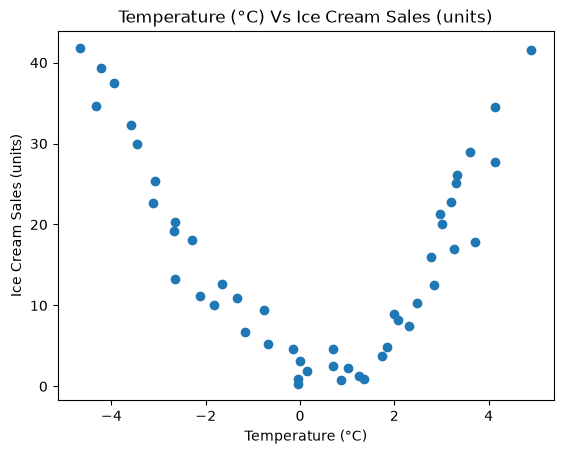

In [179]:
plt.scatter(df['Temperature (°C)'],df['Ice Cream Sales (units)'])
plt.xlabel('Temperature (°C)')
plt.ylabel('Ice Cream Sales (units)')
plt.title('Temperature (°C) Vs Ice Cream Sales (units)')
plt.show()

***Defining x and y***

In [180]:
x=df.drop(columns="Ice Cream Sales (units)")
y=df['Ice Cream Sales (units)']

***Train_test_split***

In [181]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,train_size=0.8,random_state=42)

***Model Creation for linear Regression***

In [182]:
Model=LinearRegression()

Model.fit(xtrain,ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[-1.15]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Temperature (°C)']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,17.14
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


***Model Evaluation***

In [183]:
# Train Data

ytrain_predicted=Model.predict(xtrain)

print(r2_score(ytrain,ytrain_predicted))
print(mean_absolute_error(ytrain,ytrain_predicted))
print(root_mean_squared_error(ytrain,ytrain_predicted))

0.06579063815950037
10.136398159361041
11.972117646423854


In [184]:
# Test Data

ytest_predicted=Model.predict(xtest)

print(r2_score(ytest,ytest_predicted))
print(mean_absolute_error(ytest,ytest_predicted))
print(root_mean_squared_error(ytest,ytest_predicted))

-0.5751270190188227
11.752026695440602
12.219913714640208


The regression model performed well, achieving an R2_score of 6.5%, MAE of 10.13, and RMSE of 11.97.
These result indicate that the model performance is good but Model is not good.

If we want to increase model performance we use "Polynomial feature(regression)"

### Polynomial Feature

***Model Creation for Polynomial feature***

In [185]:
Poly=PolynomialFeatures(degree=2)

updated_xtrain=Poly.fit_transform(xtrain)        # fit _transform is used to learn the pattern

updated_xtest=Poly.transform(xtest)               # transform is used to test the pattern


In [186]:
Model_poly=LinearRegression()
Model_poly.fit(updated_xtrain,ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[ 0. ,-0.71, 1.87]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.768
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](3,)","[38.94,17.19, 0. ]"


***Model Evaluation for Polynomial feature***

In [187]:
# Train Data

ytrain_predicted = Model_poly.predict(updated_xtrain)

print(r2_score(ytrain,ytrain_predicted))
print(mean_absolute_error(ytrain,ytrain_predicted))
print(root_mean_squared_error(ytrain,ytrain_predicted))

0.9413665676490518
2.5993732834161136
2.99931118717202


In [188]:
# Test Data

ytest_predicted = Model_poly.predict(updated_xtest)

print(r2_score(ytest,ytest_predicted))
print(mean_absolute_error(ytest,ytest_predicted))
print(root_mean_squared_error(ytest,ytest_predicted))

0.843055137193884
3.2299819836597274
3.857304297171988


***Conclusion***

On the basis of r2_score(Train_score,Test_score) we can say that model is  good, it's learn 94% pattern from the input
